# Computer Exercise 13.3 — Problem 2

## 부등식 제약 최적화: 로그 장벽 내부점법과 중심 경로(Central Path)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.3 Constrained Optimization — *Interior-Point / Logarithmic Barrier*
> **풀이 일자**: Day 48
> **언어**: Python 3 (NumPy / pandas / matplotlib)

## 1. 문제 (원문)

> **2.** For the inequality-constrained problem
> $$\min f(\mathbf{x})\quad\text{s.t.}\quad g_i(\mathbf{x})\ge 0,\ i=1,\dots,m,$$
> implement a **logarithmic-barrier (interior-point) method**: minimize
> $B(\mathbf{x};\mu)=f(\mathbf{x})-\mu\sum_i \ln g_i(\mathbf{x})$ for a decreasing
> sequence $\mu\to 0^{+}$, using a damped Newton iteration that stays strictly
> feasible. Trace the **central path** $\mathbf{x}(\mu)$, monitor the duality
> gap, and visualize the path inside the feasible region. Use
> $\min (x-2)^2+(y-2)^2$ s.t. $x+y\le 2,\ x\ge 0,\ y\ge 0$.

### 한국어 풀이용 정리
부등식 제약은 경계에서 미분 불연속을 만든다. **로그 장벽**은 실현가능 영역의 경계에 다가갈수록
$-\mu\ln g_i\to+\infty$ 로 치솟아 반복점을 **내부에 가둔다**. 장벽 모수 $\mu$ 를 0으로 줄이면
최소점이 진짜 해(경계 위)로 다가가며, 그 궤적이 **중심 경로**다.
무제약 최소 $(2,2)$ 는 $x+y\le2$ 를 위반하므로, 제약해는 경계 $x+y=2$ 위의 $(1,1)$ 이다.

## 2. 수학적 배경

### 2.1 장벽함수
$$\boxed{\,B(\mathbf{x};\mu)=f(\mathbf{x})-\mu\sum_{i=1}^m \ln g_i(\mathbf{x})\,},\qquad g_i(\mathbf{x})>0.$$
$\mu>0$ 가 클수록 강하게 내부로 밀고, $\mu\to0$ 이면 원래 문제로 수렴한다.

### 2.2 중심 경로와 KKT
$B$ 의 정상조건 $\nabla f-\mu\sum_i \dfrac{\nabla g_i}{g_i}=0$ 에서 $\lambda_i:=\mu/g_i>0$ 로 두면
$$\nabla f=\sum_i\lambda_i\nabla g_i,\qquad \lambda_i\,g_i=\mu.$$
이는 **완화된 상보성(perturbed complementarity)** $\lambda_i g_i=\mu$ 를 갖는 KKT 조건이다.
$\mu\to0$ 이면 $\lambda_i g_i\to0$ — 정확한 상보성 회복.

### 2.3 쌍대 간격(duality gap)
중심 경로 위에서 쌍대 간격은
$$\text{gap}=\sum_i\lambda_i g_i = m\,\mu,$$
즉 제약 개수 $m$ 에 $\mu$ 를 곱한 값으로 직접 추적할 수 있다.

### 2.4 감쇠 뉴턴(damped Newton)
$$\nabla^2 B=\nabla^2 f+\mu\sum_i\frac{\nabla g_i\,\nabla g_i^{\top}}{g_i^2}-\mu\sum_i\frac{\nabla^2 g_i}{g_i}.$$
선형 제약이면 $\nabla^2 g_i=0$. 뉴턴 스텝 $\Delta=-(\nabla^2B)^{-1}\nabla B$ 에 대해
모든 $g_i>0$ 을 유지하도록 step 길이 $t$ 를 backtracking 한다.

## 3. 풀이 흐름

1. $f=(x-2)^2+(y-2)^2$ 와 세 제약 $g_1=2-x-y,\ g_2=x,\ g_3=y$ (모두 $\ge0$) 정의.
2. 장벽함수 $B$, 그 기울기·헤시안을 해석적으로 구현.
3. **감쇠 뉴턴**: 뉴턴 방향 + feasibility를 지키는 backtracking line search.
4. $\mu\in\{10,1,10^{-1},\dots,10^{-6}\}$ 로 줄이며 warm start — 각 $\mu$ 의 중심점 $\mathbf{x}(\mu)$ 기록.
5. 중심점, 해 $(1,1)$ 까지 거리, **쌍대 간격 $3\mu$** 를 표로.
6. 실현가능 삼각형 영역 + 중심 경로 + 목적함수 등고선 시각화.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.4e}')

# ----- min (x-2)^2+(y-2)^2  s.t. g1=2-x-y>=0, g2=x>=0, g3=y>=0 -----
def f(p):  x,y=p; return (x-2)**2 + (y-2)**2
def gf(p): x,y=p; return np.array([2*(x-2), 2*(y-2)])
# 제약 g_i>=0 와 기울기
G  = [lambda p: 2-p[0]-p[1], lambda p: p[0], lambda p: p[1]]
dG = [np.array([-1.0,-1.0]), np.array([1.0,0.0]), np.array([0.0,1.0])]
x_sol = np.array([1.0,1.0])      # 제약해 (경계 x+y=2 위)
print("무제약 최소 (2,2) 는 x+y<=2 위반 → 제약해는 (1,1)")

무제약 최소 (2,2) 는 x+y<=2 위반 → 제약해는 (1,1)


In [2]:
def barrier_val(p, mu):
    gs=[g(p) for g in G]
    if min(gs)<=0: return np.inf
    return f(p) - mu*sum(np.log(g) for g in gs)

def barrier_grad(p, mu):
    g=gf(p).copy()
    for gi,dgi in zip(G,dG): g -= mu*dgi/gi(p)
    return g

def barrier_hess(p, mu):
    H=2*np.eye(2)               # Hf
    for gi,dgi in zip(G,dG): H += mu*np.outer(dgi,dgi)/gi(p)**2
    return H

def newton_barrier(x0, mu, tol=1e-10, maxit=100):
    x=np.array(x0,float)
    for _ in range(maxit):
        grad=barrier_grad(x,mu)
        if np.linalg.norm(grad)<tol: break
        d=-np.linalg.solve(barrier_hess(x,mu), grad)
        t=1.0
        while min(g(x+t*d) for g in G)<=0: t*=0.5   # feasibility
        f0=barrier_val(x,mu)
        while barrier_val(x+t*d,mu) > f0 + 1e-4*t*grad@d: t*=0.5  # Armijo
        x=x+t*d
    return x

In [3]:
mus=[10.0**k for k in range(1,-7,-1)]   # 10 ... 1e-6
x=np.array([0.5,0.5]); rows=[]
for mu in mus:
    x=newton_barrier(x, mu)
    rows.append({'mu':mu,'x':x[0],'y':x[1],
                 'dist_to_sol':np.linalg.norm(x-x_sol),
                 'duality_gap(3mu)':3*mu,'f':f(x)})
df=pd.DataFrame(rows); df

,mu,x,y,dist_to_sol,duality_gap(3mu),f
0,1.0000e+01,7.0279e-01,7.0279e-01,4.2031e-01,3.0000e+01,3.3655e+00
1,1.0000e+00,8.5542e-01,8.5542e-01,2.0447e-01,3.0000e+00,2.6201e+00
2,1.0000e-01,9.7673e-01,9.7673e-01,3.2905e-02,3.0000e-01,2.0942e+00
3,1.0000e-02,9.9752e-01,9.9752e-01,3.5092e-03,3.0000e-02,2.0099e+00
4,1.0000e-03,9.9975e-01,9.9975e-01,3.5329e-04,3.0000e-03,2.0010e+00
5,1.0000e-04,9.9998e-01,9.9998e-01,3.5353e-05,3.0000e-04,2.0001e+00
6,1.0000e-05,1.0000e+00,1.0000e+00,3.5355e-06,3.0000e-05,2.0000e+00
7,1.0000e-06,1.0000e+00,1.0000e+00,3.5355e-07,3.0000e-06,2.0000e+00


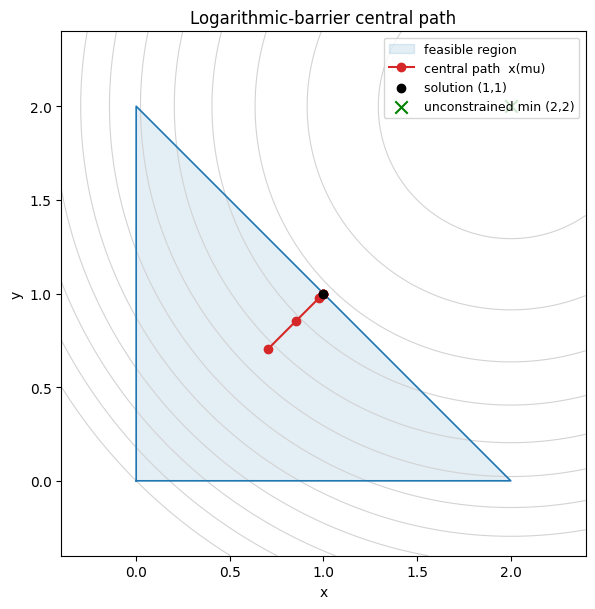

최종 mu=1e-06: x=(1.000000,1.000000), gap=3.0e-06


In [4]:
# ----- 실현가능 영역 + 중심 경로 + 등고선 -----
fig, ax = plt.subplots(figsize=(6.8,6.2))
gx=np.linspace(-0.4,2.4,300); gy=np.linspace(-0.4,2.4,300)
GX,GY=np.meshgrid(gx,gy)
F=(GX-2)**2+(GY-2)**2
cs=ax.contour(GX,GY,F,levels=np.linspace(0.5,8,12),colors='lightgray',linewidths=0.8)
# 실현가능 삼각형: (0,0),(2,0),(0,2)
tri=np.array([[0,0],[2,0],[0,2],[0,0]])
ax.fill(tri[:,0],tri[:,1],alpha=0.12,color='tab:blue',label='feasible region')
ax.plot(tri[:,0],tri[:,1],color='tab:blue',lw=1.2)
path=df[['x','y']].values
ax.plot(path[:,0],path[:,1],'o-',color='tab:red',label='central path  x(mu)')
ax.scatter(*x_sol,color='black',zorder=5,label='solution (1,1)')
ax.scatter(2,2,marker='x',color='green',s=80,label='unconstrained min (2,2)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
ax.set_title('Logarithmic-barrier central path'); ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()
print(f"최종 mu={df['mu'].iloc[-1]:.0e}: x=({df['x'].iloc[-1]:.6f},{df['y'].iloc[-1]:.6f}), gap={df['duality_gap(3mu)'].iloc[-1]:.1e}")

## 4. 결과 해석

1. **내부 시작 → 경계 수렴**: 시작점 $(0.5,0.5)$ 는 삼각형 내부이고, $\mu$ 가 줄면서 중심 경로가 목적함수가 끌어당기는 $(2,2)$ 방향으로 가다가 제약 경계 $x+y=2$ 에서 멈춰 $(1,1)$ 로 수렴한다.
2. **중심 경로의 의미**: 각 $\mu$ 의 중심점은 "목적함수 감소"와 "경계로부터의 거리(장벽)" 사이의 타협점이다. $\mu$ 가 클수록 안쪽(중심 쪽), 작을수록 해에 밀착한다.
3. **쌍대 간격 $=3\mu$**: 제약이 3개이므로 gap이 $3\mu$ 로 정확히 줄어든다 — $\mu$ 만 봐도 최적성 정밀도를 안다. $\mu=10^{-6}$ 에서 gap $\approx3\times10^{-6}$.
4. **감쇠 뉴턴의 역할**: feasibility backtracking이 없으면 뉴턴 스텝이 $\ln$ 정의역 밖($g_i\le0$)으로 나가 발산한다. step을 절반씩 줄여 항상 내부에 머무는 것이 내부점법의 핵심.
5. **벌점법과의 대비(CE 1)**: 외부 벌점법은 실현불가능 쪽에서 접근하지만, 내부점법은 **항상 실현가능**한 점들만 생성한다 — 실시간 제어 등에서 중요한 성질.

> **결론**: 로그 장벽 내부점법은 반복점을 실현가능 영역 내부에 유지하면서 $\mu\to0$ 으로 중심 경로를 따라 최적해에 도달하며, 쌍대 간격이 $m\mu$ 로 명시적으로 통제된다.

**다음 문제로의 연결**: 부등식 제약을 비선형으로 다뤘으니, CE 3에서는 **선형계획(LP)** 을 단체법(simplex)으로 직접 풀고 `scipy.linprog` 와 대조하며 꼭짓점 이동을 시각화한다.